In [1]:
from langgraph.graph import StateGraph, END, START
from typing import TypedDict
from langchain_groq import ChatGroq
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
llm = ChatGroq(model= "openai/gpt-oss-120b")
llm.invoke("who is viral kohli in 10 words").content

'Indian cricket star, prolific batsman, former captain, global record-breaking scorer.'

In [78]:
from typing import Annotated
from operator import add
class Batsmanstate(TypedDict):
    run:int
    ball:int
    fours:int
    sixs:int
    sr:Annotated[float,add]
    bpb:float
    boundary_percentage:float

In [79]:
def calculate_sr(state:Batsmanstate)->Batsmanstate:
    runs = state["run"]
    balls = state["ball"]
    sr = (runs/balls)*100
    state["sr"] = sr
    return {"aj":sr}

def calculate_bpb(state:Batsmanstate)->Batsmanstate:
    fours = state["fours"]
    sixs = state["sixs"]
    balls = state["ball"]
    bpb = ((fours+sixs)/balls)*100
    state["sr"] = bpb
    return {"bpb":bpb}

In [80]:
graph = StateGraph(Batsmanstate)
graph.add_node("calculate_sr",calculate_sr)
graph.add_node("calculate_bpb",calculate_bpb)
# graph.add_node("calcullate_boundary_percentage",calculate_boundary_percentage)

In [81]:
graph.add_edge(START,"calculate_sr")
graph.add_edge(START,"calculate_bpb")
graph.add_edge("calculate_bpb",END)
graph.add_edge("calculate_bpb",END)

In [82]:
workflow = graph.compile()

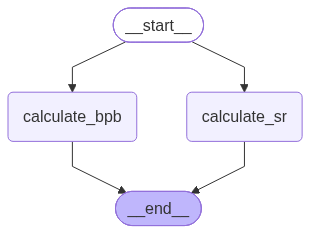

In [83]:
from IPython.display import Image
Image(workflow.get_graph().draw_mermaid_png())

In [84]:
initial_state = {"ball":10,"run":30,"sixs":3,"fours":2}
workflow.invoke(initial_state)

{'run': 30, 'ball': 10, 'fours': 2, 'sixs': 3, 'sr': 0.0, 'bpb': 50.0}

Parallal_workflow_with_llm_using_Structured Output 